<a href="https://colab.research.google.com/github/fboldt/aulas-am-bsi/blob/main/aula15b_kmeans_as_fs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from sklearn.datasets import load_digits
X, y = load_digits(return_X_y=True)

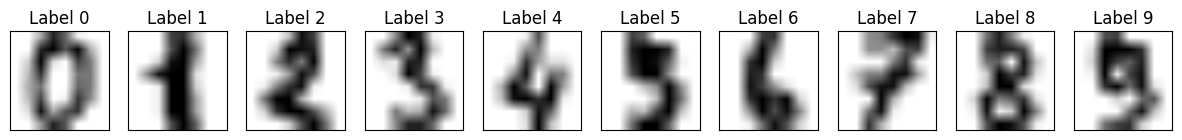

In [15]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 10, figsize=(15,3))
for ax, image, label in zip(axes, X, y):
  ax.imshow(image.reshape(8, 8), cmap="gray_r", interpolation='bilinear')
  ax.set_title(f'Label {label}')
  ax.set_xticks([])
  ax.set_yticks([])
plt.show()


In [16]:
from sklearn.linear_model import RidgeClassifier
from sklearn.model_selection import cross_val_score

model = RidgeClassifier()
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.8881522748375115


In [20]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5)
kmeans.fit(X)
kmeans.transform(X)

array([[45.99854152, 33.43605959, 40.10117846, 40.42069576, 25.87610379],
       [37.19888457, 42.51326433, 34.0520279 , 31.47248444, 46.53247047],
       [39.73631375, 44.51611356, 38.9727011 , 36.77210812, 42.39073495],
       ...,
       [37.96412976, 40.62034093, 35.05783625, 33.26072398, 37.74868645],
       [44.28055303, 28.01769243, 36.87837155, 39.56560926, 34.21262187],
       [36.14751754, 32.97642902, 41.11033205, 38.64527651, 33.47392261]])

In [23]:
from sklearn.pipeline import Pipeline

model = Pipeline([
  ('kmeans', KMeans(n_clusters=32)),
  ('classifier', RidgeClassifier())
])
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.9170953265242959


In [25]:
model = Pipeline([
  ('kmeans', KMeans(n_clusters=128)),
  ('classifier', RidgeClassifier())
])
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.9571618693902817


In [26]:
!pip install optuna -qq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.8 MB/s eta 0:00:00


In [27]:
import optuna

def objective(trial):
  n_clusters = trial.suggest_int('n_clusters', 2, 256)
  model = Pipeline([
      ('kmeans', KMeans(n_clusters=n_clusters)),
      ('classifier', RidgeClassifier())
  ])
  scores = cross_val_score(model, X, y, cv=5)
  return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print(study.best_params)
print(study.best_value)

[I 2026-10-06 15:24:37,704] A new study created in memory with name: no-name-152d1357-dbbc-4b81-828d-d5f5edc17cf3
[I 2026-10-06 15:24:38,868] Trial 0 finished with value: 0.9632760755184153 and parameters: {'n_clusters': 164}. Best is trial 0 with value: 0.9632760755184153.
[I 2026-10-06 15:24:39,354] Trial 1 finished with value: 0.9543809965954813 and parameters: {'n_clusters': 95}. Best is trial 0 with value: 0.9632760755184153.
[I 2026-10-06 15:24:39,565] Trial 2 finished with value: 0.9226586196224078 and parameters: {'n_clusters': 31}. Best is trial 0 with value: 0.9632760755184153.
[I 2026-10-06 15:24:39,875] Trial 3 finished with value: 0.9471371092541009 and parameters: {'n_clusters': 61}. Best is trial 0 with value: 0.9632760755184153.
[I 2026-10-06 15:24:41,052] Trial 4 finished with value: 0.962726709996905 and parameters: {'n_clusters': 176}. Best is trial 0 with value: 0.9632760755184153.
[I 2026-10-06 15:24:42,316] Trial 5 finished with value: 0.9604998452491488 and param

{'n_clusters': 224}
0.9710708758898173


In [28]:
model = Pipeline([
    ('kmeans', KMeans(n_clusters=study.best_params['n_clusters'])),
    ('classifier', RidgeClassifier())
])
scores = cross_val_score(model, X, y, cv=5)
print(scores.mean())

0.9655122253172392


In [29]:
from sklearn.base import BaseEstimator, ClassifierMixin

class OptunaKMeansRidgeClassifier(BaseEstimator, ClassifierMixin):
  def __init__(self, n_trials=20):
    self.n_trials = n_trials

  def fit(self, X, y):
    def objective(trial):
      n_clusters = trial.suggest_int('n_clusters', 2, 256)
      model = Pipeline([
          ('kmeans', KMeans(n_clusters=n_clusters)),
          ('classifier', RidgeClassifier())
      ])
      scores = cross_val_score(model, X, y, cv=5)
      return scores.mean()
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=self.n_trials)
    self.model = Pipeline([
        ('kmeans', KMeans(n_clusters=study.best_params['n_clusters'])),
        ('classifier', RidgeClassifier())
    ])
    self.model.fit(X, y)
    return self

  def predict(self, X):
    return self.model.predict(X)

scores = cross_val_score(OptunaKMeansRidgeClassifier(), X, y, cv=5)
print(scores.mean())

[I 2026-10-06 15:33:49,930] A new study created in memory with name: no-name-f1bcfe36-986a-4392-a169-7f8a88f57713
[I 2026-10-06 15:33:51,486] Trial 0 finished with value: 0.9652148664343786 and parameters: {'n_clusters': 194}. Best is trial 0 with value: 0.9652148664343786.
[I 2026-10-06 15:33:52,957] Trial 1 finished with value: 0.9610385210994966 and parameters: {'n_clusters': 181}. Best is trial 0 with value: 0.9652148664343786.
[I 2026-10-06 15:33:54,318] Trial 2 finished with value: 0.9603416569879984 and parameters: {'n_clusters': 225}. Best is trial 0 with value: 0.9652148664343786.
[I 2026-10-06 15:33:54,788] Trial 3 finished with value: 0.9575517808749515 and parameters: {'n_clusters': 106}. Best is trial 0 with value: 0.9652148664343786.
[I 2026-10-06 15:33:55,263] Trial 4 finished with value: 0.9478053619821913 and parameters: {'n_clusters': 94}. Best is trial 0 with value: 0.9652148664343786.
[I 2026-10-06 15:33:55,904] Trial 5 finished with value: 0.9589455090979481 and pa

0.9666186939028163
